In [1]:
import torch
import matplotlib.pyplot as plt
import h5py
import numpy as np
import galsim
from dataset import SuperResolutionDataset
from model import SuperResolutionDiffusion, SuperResDiffusionUNet, Upsampler
from torch.utils.data import DataLoader


In [2]:
MODEL_PATH = "/home/shemmati/Work/Projects/superNISP/code/wandb/latest-run/files/best_model.pth" 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Load dataset ----
test_dataset = SuperResolutionDataset(
    "../data/Nisp_train_cosmos.hdf5",
    "../data/Nircam_train_cosmos.hdf5",
    split="test",
    sample_fraction=1.0  # use full test set for evaluation
)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)


# ---- Load model ----
unet = SuperResDiffusionUNet(in_channels=1, out_channels=1, hidden_dim=64)
upsampler = Upsampler(in_channels=1, out_channels=1, upscale_factor=2)
model = SuperResolutionDiffusion(unet, upsampler).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

SuperResolutionDiffusion(
  (upsampler): Upsampler(
    (conv1): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (pixel_shuffle): PixelShuffle(upscale_factor=2)
    (relu): ReLU()
    (conv2): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (diffusion): DiffusionModel(
    (unet): SuperResDiffusionUNet(
      (encoder1): Sequential(
        (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (1): ReLU()
      )
      (encoder2): Sequential(
        (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (1): ReLU()
      )
      (encoder3): Sequential(
        (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (1): ReLU()
      )
      (condition_proj): Conv2d(1, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (cross_attention): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
      (decoder1): Sequential(
        (0): ConvTranspose2d(256, 128, kern

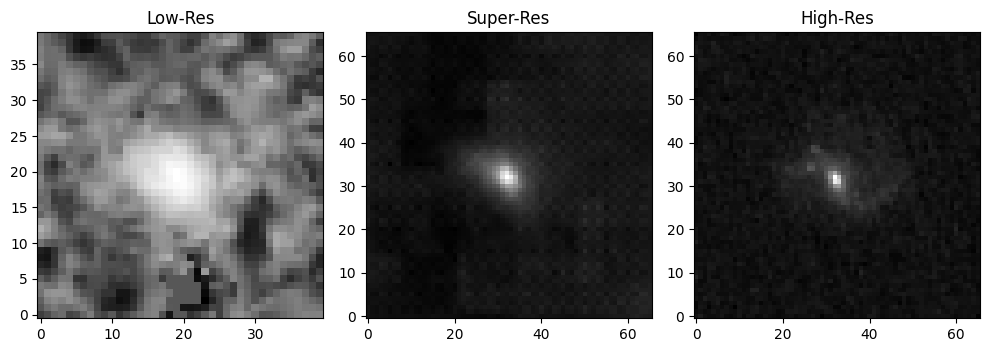

In [3]:
idx = np.random.randint(0, len(test_dataset))
lr_img, hr_img = test_dataset[idx]
lr_img_tensor = lr_img.unsqueeze(0).to(DEVICE)
t_test = torch.zeros((1,), dtype=torch.long, device=DEVICE)
with torch.no_grad():
    sr_img = model(lr_img_tensor, t_test).detach().cpu().squeeze(0)


fig, axs = plt.subplots(1, 3, figsize=(10, 3.4))
axs[0].imshow(lr_img[0].cpu().numpy(), origin='lower', cmap='gray')
axs[0].set_title("Low-Res")
axs[1].imshow(sr_img[0].numpy(), origin='lower', cmap='gray')  # already detached
axs[1].set_title("Super-Res")
axs[2].imshow(hr_img[0].cpu().numpy(), origin='lower', cmap='gray')
axs[2].set_title("High-Res")
plt.tight_layout()
plt.show()



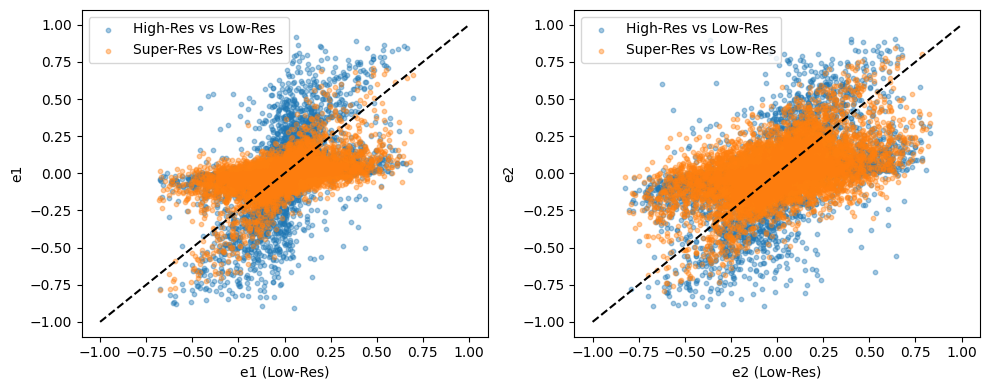

In [49]:
# Initialize arrays to store moments
e1_lr, e2_lr, g1_lr, g2_lr = [], [], [], []
e1_hr, e2_hr, g1_hr, g2_hr = [], [], [], []
e1_sr, e2_sr, g1_sr, g2_sr = [], [], [], []

# Define once
def get_moments(image_np):
    try:
        img = galsim.ImageF(image_np.shape[0], image_np.shape[1])
        img.array = image_np
        res = img.FindAdaptiveMom()
        return [res.observed_e1, res.observed_e2, res.observed_shape.g1, res.observed_shape.g2]
    except:
        return [np.nan] * 4

# Loop over dataset
for i in range(len(test_dataset)):
    lr_img, hr_img = test_dataset[i]
    lr_img_tensor = lr_img.unsqueeze(0).to(DEVICE)
    t = torch.zeros((1,), dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        sr_img = model(lr_img_tensor, t).detach().cpu().squeeze(0)  # shape (1, H, W)

    # Convert all to numpy
    lr_vals = get_moments(lr_img[0].cpu().numpy())
    hr_vals = get_moments(hr_img[0].cpu().numpy())
    sr_vals = get_moments(sr_img[0].numpy())

    e1_lr.append(lr_vals[0]); e2_lr.append(lr_vals[1]); g1_lr.append(lr_vals[2]); g2_lr.append(lr_vals[3])
    e1_hr.append(hr_vals[0]); e2_hr.append(hr_vals[1]); g1_hr.append(hr_vals[2]); g2_hr.append(hr_vals[3])
    e1_sr.append(sr_vals[0]); e2_sr.append(sr_vals[1]); g1_sr.append(sr_vals[2]); g2_sr.append(sr_vals[3])

# Plot e1 and e2 comparisons
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].scatter(e1_lr, e1_hr, s=10, alpha=0.4, label='High-Res vs Low-Res')
axs[0].scatter(e1_lr, e1_sr, s=10, alpha=0.4, label='Super-Res vs Low-Res')
axs[0].plot([-1, 1], [-1, 1], 'k--')
axs[0].set_xlabel("e1 (Low-Res)")
axs[0].set_ylabel("e1")
axs[0].legend()

axs[1].scatter(e2_lr, e2_hr, s=10, alpha=0.4, label='High-Res vs Low-Res')
axs[1].scatter(e2_lr, e2_sr, s=10, alpha=0.4, label='Super-Res vs Low-Res')
axs[1].plot([-1, 1], [-1, 1], 'k--')
axs[1].set_xlabel("e2 (Low-Res)")
axs[1].set_ylabel("e2")
axs[1].legend()

plt.tight_layout()
plt.show()
